In [ ]:
import pandas as pd

# Descriptive analysis

In [ ]:
df = pd.read_csv('HRDataset_v14.csv')

In [ ]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (311, 36)


In [ ]:
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [ ]:
df.dtypes

,0
Employee_Name,object
EmpID,int64
MarriedID,int64
MaritalStatusID,int64
GenderID,int64
EmpStatusID,int64
DeptID,int64
PerfScoreID,int64
FromDiversityJobFairID,int64
Salary,int64


In [ ]:
df.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,303.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,16.845659,6555.482315,14.570957,4.110000,3.890675,1.218650,0.414791,10.237942
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,6.223419,16908.396884,8.078306,0.789938,0.909241,2.349421,1.294519,5.852596
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,10.000000,3.690000,3.000000,0.000000,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,15.000000,4.280000,4.000000,0.000000,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,20.000000,2355.000000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000


In [ ]:
print(df.isnull().sum())

Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

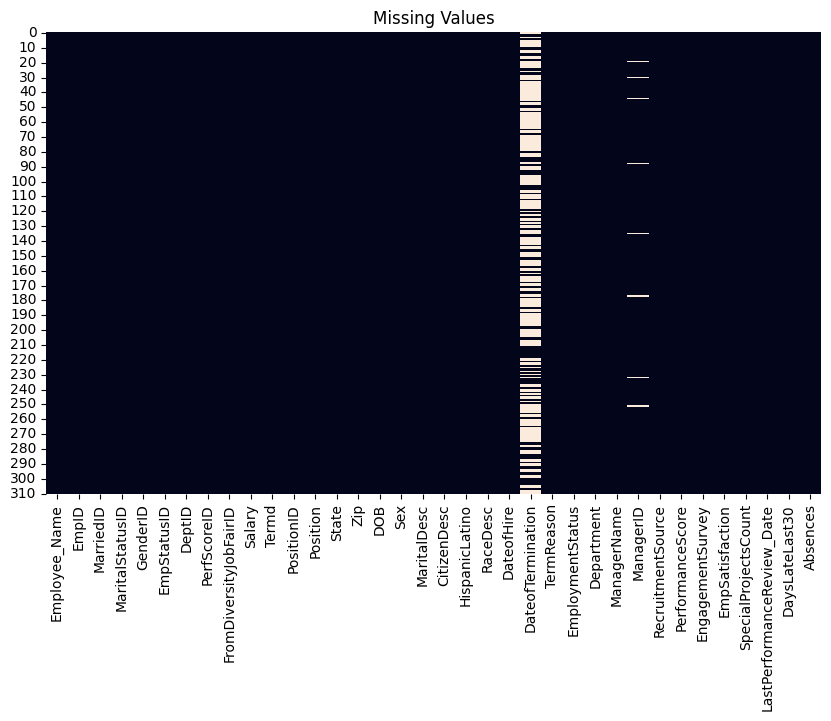

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

# Pre-processing

In [ ]:
# Conversion des colonnes de dates en format datetime
# Cela permet de faire des calculs (âge, ancienneté, etc.)

df["DOB"] = pd.to_datetime(df["DOB"])
df["DateofHire"] = pd.to_datetime(df["DateofHire"])
df["LastPerformanceReview_Date"] = pd.to_datetime(df["LastPerformanceReview_Date"])

# Date actuelle utilisée comme référence
today = pd.to_datetime("today")

# Calcul de l'âge de l'employé
# (différence entre aujourd'hui et la date de naissance)
df["Age"] = (today - df["DOB"]).dt.days // 365

# Calcul de l'ancienneté dans l'entreprise
# (différence entre aujourd'hui et la date d'embauche)
df["Tenure"] = (today - df["DateofHire"]).dt.days // 365

/tmp/ipykernel_166/4047378545.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DOB"] = pd.to_datetime(df["DOB"])


In [ ]:
# Liste des colonnes à supprimer
cols_to_drop = [
    "Employee_Name",            # donnée personnelle
    "EmpID",                    # identifiant unique (pas utile pour prédiction)
    "Zip",                      # localisation trop spécifique
    "ManagerName",              # identifiant personnel
    "DOB",                      # remplacé par Age
    "DateofHire",               # remplacé par Tenure
    "DateofTermination",        # contient l'information finale
    "LastPerformanceReview_Date" # date brute, moins utile que dérivées
]

# Suppression des colonnes
df = df.drop(columns=cols_to_drop, errors="ignore")

In [ ]:
# Sélection des colonnes contenant du texte
categorical_cols = df.select_dtypes(include=["object"]).columns

# Affichage des colonnes catégorielles
print("Colonnes catégorielles :")
print(categorical_cols)

Colonnes catégorielles :
Index(['Position', 'State', 'Sex', 'MaritalDesc', 'CitizenDesc',
       'HispanicLatino', 'RaceDesc', 'TermReason', 'EmploymentStatus',
       'Department', 'RecruitmentSource', 'PerformanceScore'],
      dtype='object')


In [ ]:
# Transformation en variables numériques avec One Hot Encoding
# Exemple : Department_IT, Department_Sales, etc.

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
# Définition de la variable cible
target = "Termd"

# Calcul de la matrice de corrélation
corr = df.corr()

# Corrélation des variables avec la démission
corr_target = corr[target].sort_values(ascending=False)

# Affichage des variables les plus corrélées
print("Variables les plus corrélées avec la démission :")
print(corr_target.head(20))

Variables les plus corrélées avec la démission :
Termd                                      1.000000
EmpStatusID                                0.948058
EmploymentStatus_Voluntarily Terminated    0.886252
Tenure                                     0.397708
EmploymentStatus_Terminated for Cause      0.328562
TermReason_unhappy                         0.306305
TermReason_more money                      0.270150
RecruitmentSource_Google Search            0.254683
TermReason_career change                   0.243549
TermReason_hours                           0.229241
TermReason_attendance                      0.214082
ManagerID                                  0.209113
Department_Production                      0.190312
TermReason_relocation out of area          0.180340
TermReason_return to school                0.180340
TermReason_performance                     0.161038
TermReason_military                        0.161038
TermReason_no-call, no-show                0.161038
TermReason_reti

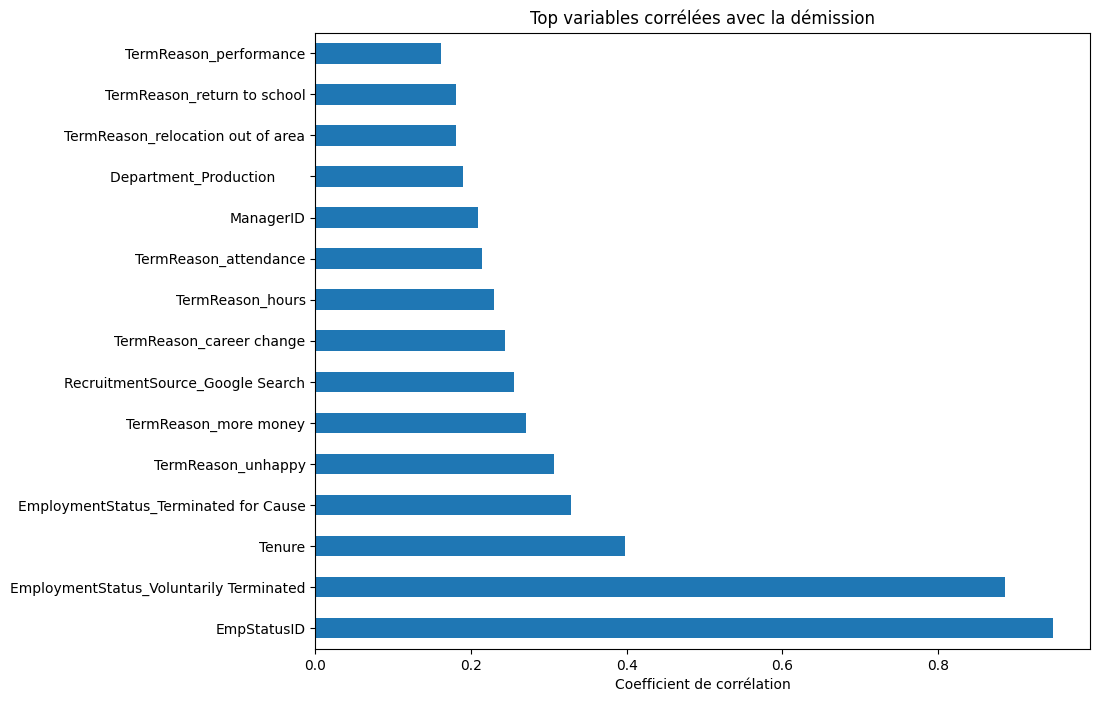

In [ ]:
# Graphique des 15 variables les plus corrélées avec la démission
plt.figure(figsize=(10,8))

corr_target.drop(target).head(15).plot(kind="barh")

plt.title("Top variables corrélées avec la démission")
plt.xlabel("Coefficient de corrélation")
plt.show()

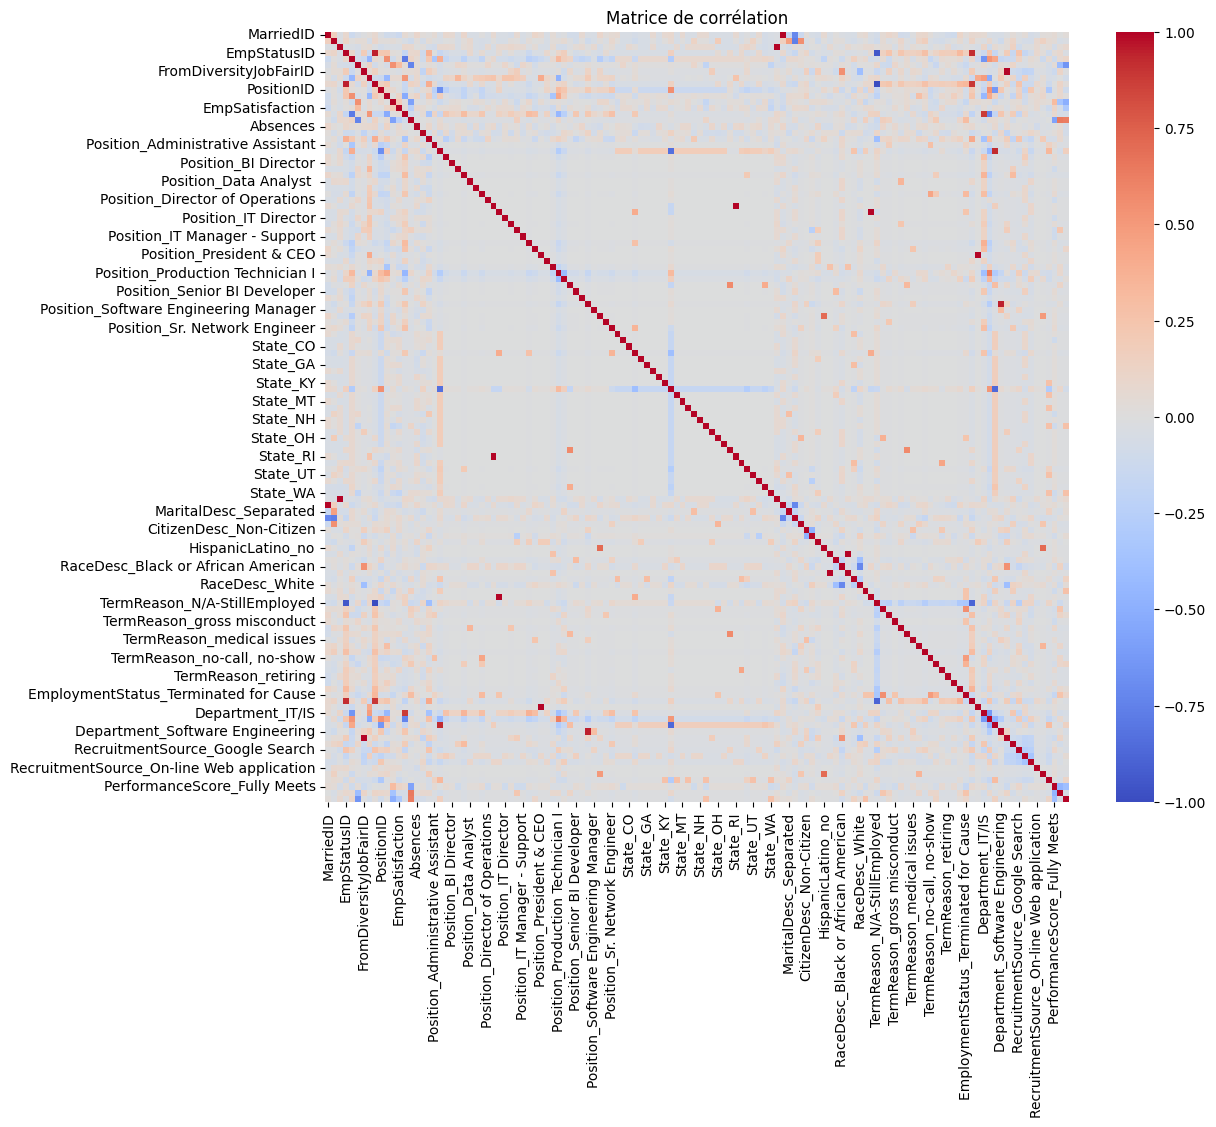

In [ ]:
# Visualisation de la matrice de corrélation complète
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Matrice de corrélation")
plt.show()

# Prediction

## Random Forest Classifier

Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        22

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63



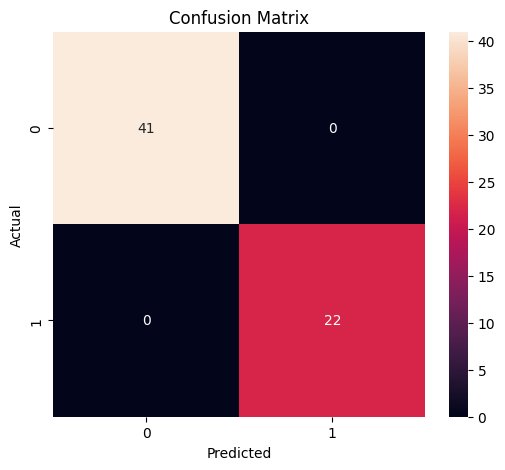

In [ ]:
# Variables explicatives
X = df.drop("Termd", axis=1)

# Variable cible
y = df["Termd"]



from sklearn.model_selection import train_test_split

# Division du dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,     # 20% pour le test
    random_state=42    # reproductibilité
)

from sklearn.preprocessing import StandardScaler

# Création du scaler
scaler = StandardScaler()

# Normalisation des données d'entraînement
X_train = scaler.fit_transform(X_train)

# Application de la même transformation sur le test
X_test = scaler.transform(X_test)

from sklearn.ensemble import RandomForestClassifier

# Création du modèle
model = RandomForestClassifier(
    n_estimators=200,   # nombre d'arbres
    random_state=42
)

# Entraînement du modèle
model.fit(X_train, y_train)

# Prédiction sur le dataset de test
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy globale
print("Accuracy :", accuracy_score(y_test, y_pred))

# Rapport détaillé
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

TermReason_N/A-StillEmployed               0.292339
EmpStatusID                                0.244486
EmploymentStatus_Voluntarily Terminated    0.163630
Tenure                                     0.051987
EmploymentStatus_Terminated for Cause      0.029561
ManagerID                                  0.024007
TermReason_more money                      0.011567
TermReason_unhappy                         0.010809
RecruitmentSource_Google Search            0.010697
Salary                                     0.010386
EngagementSurvey                           0.009125
Age                                        0.008444
PositionID                                 0.006887
Absences                                   0.006793
TermReason_career change                   0.006194
dtype: float64


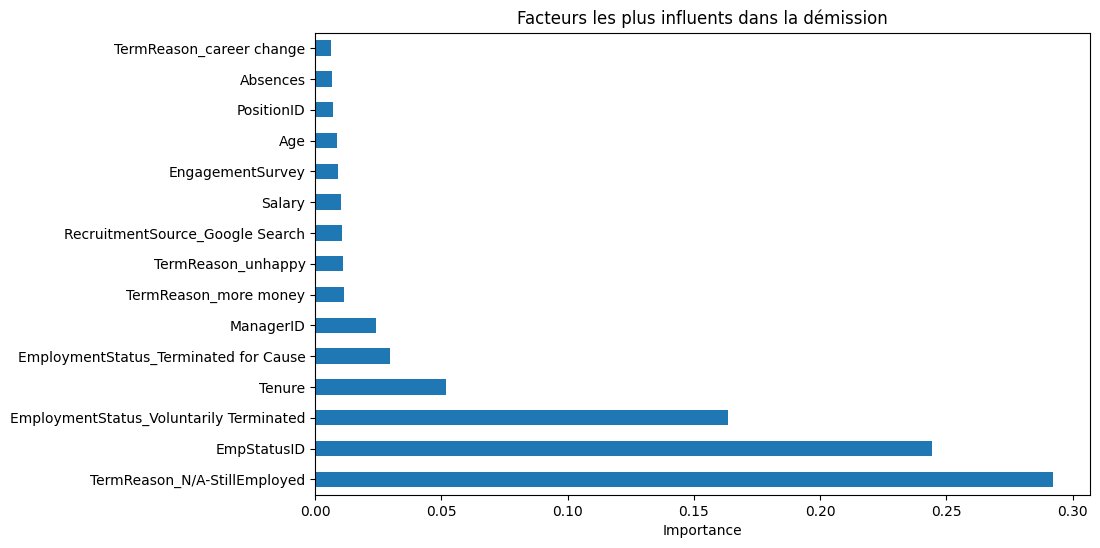

In [ ]:
# Calcul de l'importance des variables
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Affichage des variables les plus importantes
print(feature_importance.head(15))

plt.figure(figsize=(10,6))

feature_importance.head(15).plot(kind="barh")

plt.title("Facteurs les plus influents dans la démission")
plt.xlabel("Importance")

plt.show()

In [ ]:
!pip install shap

In [ ]:
#utilisation de shap pour faire une ia

import shap
# création de l'objet explainer
explainer = shap.TreeExplainer(model)

# calcul des valeurs SHAP sur les données test
shap_values = explainer.shap_values(X_test)
# graphique global des variables importantes
shap.summary_plot(shap_values[1], X_test, feature_names=X.columns)
# expliquer la prédiction d'un employé
shap.plots.force(
    explainer.expected_value[1],
    shap_values[1][0],
    features=X_test[0],
    feature_names=X.columns
)
shap.plots.waterfall(shap_values[1][0])

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.